## Importaciones de librerías

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Carga de datos y Visualización rápida

In [2]:
PATH = '..\\data\\sakila.csv'
df = pd.read_csv(PATH)
df.head()

,firt_name,last_name,email,active,address,district,postal_code,phone,city,country,rental_date,return_date,amount,payment_date,rental_duration
0,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-05-25 11:30:37,2005-06-03 12:00:37,2.99,2005-05-25 11:30:37,9
1,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-05-28 10:35:23,2005-06-03 06:32:23,0.99,2005-05-28 10:35:23,6
2,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-15 00:54:12,2005-06-23 02:42:12,5.99,2005-06-15 00:54:12,8
3,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-15 18:02:53,2005-06-19 15:54:53,0.99,2005-06-15 18:02:53,4
4,mary,smith,mary.smith@sakilacustomer.org,1,1913 hanoi way,nagasaki,35200,28303384290,sasebo,japan,2005-06-15 21:08:46,2005-06-25 02:26:46,9.99,2005-06-15 21:08:46,10


In [15]:
print(f'El dataset tiene {df.shape[1]} columnas')
print(f'El dataset tiene {df.shape[0]} filas/registros')

El dataset tiene 15 columnas
El dataset tiene 15861 filas/registros


In [19]:
print(f'El dataset tiene {df.duplicated().sum()} filas duplicadas.')

El dataset tiene 0 filas duplicadas.


In [ ]:
# Suma de valores nulos por columna
df.isnull().sum()

firt_name            0
last_name            0
email                0
active               0
address              0
district           100
postal_code          0
phone                0
city                 0
country              0
rental_date          0
return_date          0
amount               0
payment_date         0
rental_duration      0
dtype: int64

In [ ]:
# Porcentaje de valores nulos por columna
round(df.isnull().sum() * 100 / len(df),2)

firt_name          0.00
last_name          0.00
email              0.00
active             0.00
address            0.00
district           0.63
postal_code        0.00
phone              0.00
city               0.00
country            0.00
rental_date        0.00
return_date        0.00
amount             0.00
payment_date       0.00
rental_duration    0.00
dtype: float64

In [ ]:
# Tipos de datos de cada columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   firt_name        15861 non-null  object 
 1   last_name        15861 non-null  object 
 2   email            15861 non-null  object 
 3   active           15861 non-null  int64  
 4   address          15861 non-null  object 
 5   district         15761 non-null  object 
 6   postal_code      15861 non-null  int64  
 7   phone            15861 non-null  int64  
 8   city             15861 non-null  object 
 9   country          15861 non-null  object 
 10  rental_date      15861 non-null  object 
 11  return_date      15861 non-null  object 
 12  amount           15861 non-null  float64
 13  payment_date     15861 non-null  object 
 14  rental_duration  15861 non-null  int64  
dtypes: float64(1), int64(4), object(10)
memory usage: 1.8+ MB


In [ ]:
# Estadísticas descriptivas para columnas numéricas
df.describe()

,active,postal_code,phone,amount,rental_duration
count,15861.000000,15861.000000,1.586100e+04,15861.000000,15861.000000
mean,0.974781,50452.519324,4.986023e+11,4.217161,5.025219
std,0.156795,28910.703531,2.995060e+11,2.360383,2.611835
min,0.000000,3.000000,8.925233e+08,0.990000,0.000000
25%,1.000000,25238.000000,2.149761e+11,2.990000,3.000000
50%,1.000000,51309.000000,4.930085e+11,3.990000,5.000000
75%,1.000000,75149.000000,7.623618e+11,4.990000,7.000000
max,1.000000,99865.000000,9.980098e+11,11.990000,10.000000


In [ ]:
# Estadísticas descriptivas para columnas categóricas
df.describe(include='object')

,firt_name,last_name,email,address,district,city,country,rental_date,return_date,payment_date
count,15861,15861,15861,15861,15761,15861,15861,15861,15861,15861
unique,591,599,599,599,375,597,108,15813,15836,15813
top,marion,hunt,eleanor.hunt@sakilacustomer.org,1952 pune lane,buenos aires,aurora,india,2005-07-29 08:40:36,2005-08-28 05:37:42,2005-07-29 08:40:36
freq,67,46,46,46,267,48,1548,2,2,2


## Creación de columnas adicionales

In [4]:
df['full_name'] = df['firt_name'] + ' ' + df['last_name']
df['rental_day'] = df['rental_date'].dt.day
df['rental_month'] = df['rental_date'].dt.month
df['rental_year'] = df['rental_date'].dt.year
df['rental_hour'] = df['rental_date'].dt.hour
df['return_day'] = df['return_date'].dt.day
df['return_month'] = df['return_date'].dt.month
df['return_year'] = df['return_date'].dt.year
df['return_hour'] = df['return_date'].dt.hour
df['day_of_week_rental'] = df['rental_date'].dt.dayofweek + 1
df['is_weekend_rental'] = df['day_of_week_rental'].apply(lambda x: 1 if x in [6, 7] else 0)
df['season'] = df['rental_month'].apply(lambda x: 'Primavera' if x.month in [3,4,5] else ('Verano' if x.month in [6,7,8] else ('Otoño' if x.month in [9,10,11] else 'Invierno')))
df['rental_hour_part_of_the_day'] = df['rental_hour'].apply(lambda x: 'Noche' if x in [0,1,2,3,4,5,6] else('Mañana' if x in [7,8,9,10,11,12] else 'Tarde'))
df['return_hour_part_of_the_day'] = df['return_hour'].apply(lambda x: 'Noche' if x in [0,1,2,3,4,5,6] else('Mañana' if x in [7,8,9,10,11,12] else 'Tarde'))

AttributeError: Can only use .dt accessor with datetimelike values

## Eliminación de las columnas que ya no nos aporta información

In [ ]:
df = df.drop(columns=['first_name', 'last_name', 'rental_date', 'return_date'], axis=1) # axis = 1 == columnas
df.head()

## Tratamiento de valores Nulos y Outliers

In [ ]:
lista_variables_numericas = []

columnas_a_ignorar = ['postal_code', 'phone', 'payment_date']

for column in df.columns:
    if column in columnas_a_ignorar or df[column].dtype == 'object' or 'return_' in column or (column.startswith('rental_') and column != 'rental_duration'):
        continue
    else:
        lista_variables_numericas.append(column)

### Tratamiento de valores Nulos

### Tratamiento de valores Outliers

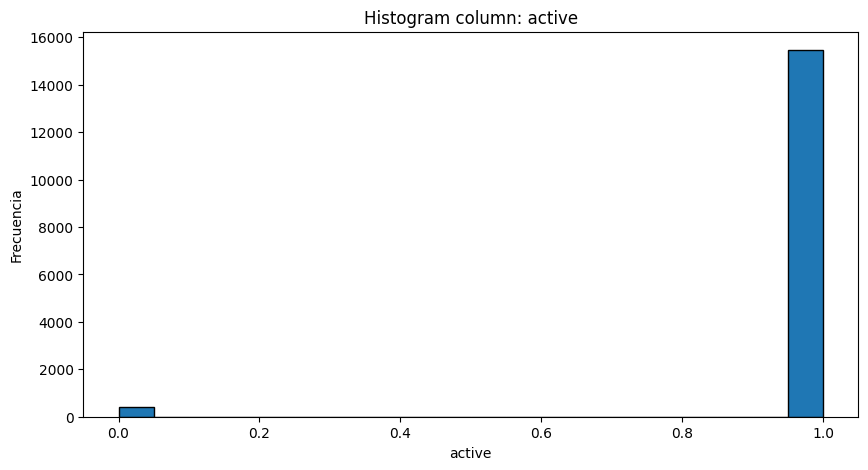

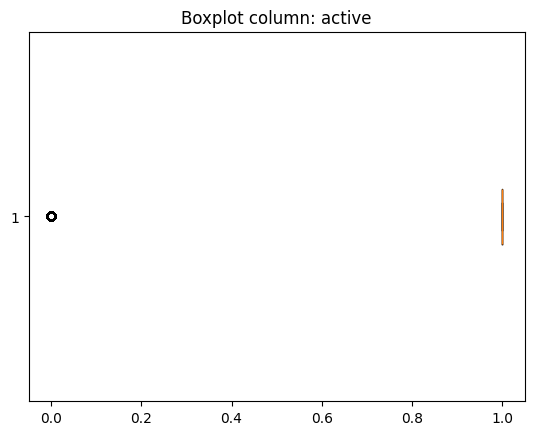

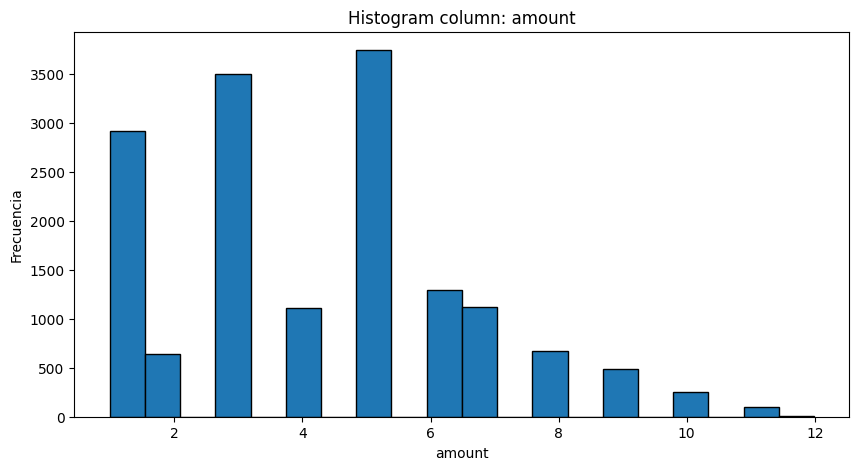

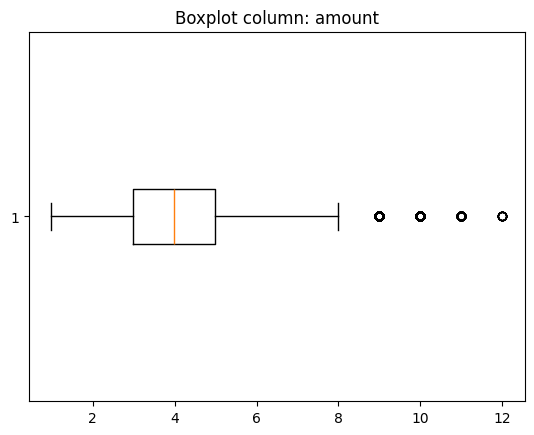

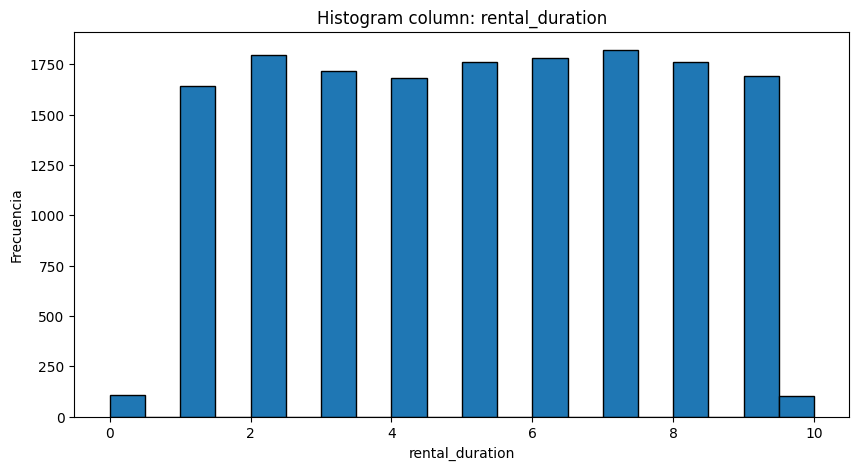

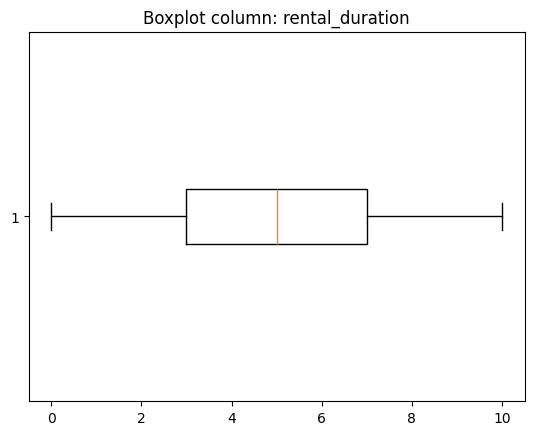

In [6]:
for column in lista_variables_numericas:
    plt.figure(figsize=(10, 5))
    plt.hist(df[column], bins=20, edgecolor='black')
    plt.title(f'Histogram column: {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.show()

    plt.boxplot(df[column], orientation='horizontal')
    plt.title(f'Boxplot column: {column}')
    plt.show()